### Round 3 Analysis - HYDROGEL_PACK

In [1]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats

from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera

import prosperity4
from prosperity4.utils.statistics_utils import compute_returns
from prosperity4.utils.dataloader import (
    load_trading_data,
    get_product_data,
    get_day_data,
    get_product_day_data,
    get_price_data,
    get_order_book_data,
    get_volume_data,
    convert_timestamp,
)


plt.style.use("dark_background")
sns.set_palette("pastel")

### Data Loading

In [60]:
REPO_ROOT = Path(prosperity4.__file__).parents[1]
DATA_FOLDER = REPO_ROOT / "prosperity4" / "round4" / "data"
ROUND_NUM = 4
DAYS = [1, 2, 3]
SYMBOL = "HYDROGEL_PACK"

data = load_trading_data(DATA_FOLDER, ROUND_NUM, DAYS)
prices_df = data.get("prices")
trades_df = data.get("trades")

print("Prices Shape :", prices_df.shape if prices_df is not None else None)
print("Trades Shape :", trades_df.shape if trades_df is not None else None)
print("\n--- Prices Head ---")
display(prices_df.head())
print("\n--- Trades Head ---")
display(trades_df.head())

Prices Shape : (360000, 17)
Trades Shape : (4281, 8)

--- Prices Head ---


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,1,0,VELVETFRUIT_EXTRACT,5242,54,NaN,NaN,NaN,NaN,5248,54,NaN,NaN,NaN,NaN,5245.0,0.0
1,1,0,HYDROGEL_PACK,9950,13,9947.0,23.0,NaN,NaN,9966,13,9968.0,23.0,NaN,NaN,9958.0,0.0
2,1,0,VEV_6000,0,22,NaN,NaN,NaN,NaN,1,22,NaN,NaN,NaN,NaN,0.5,0.0
3,1,0,VEV_5000,248,19,NaN,NaN,NaN,NaN,254,6,255.0,13.0,NaN,NaN,251.0,0.0
4,1,0,VEV_6500,0,18,NaN,NaN,NaN,NaN,1,18,NaN,NaN,NaN,NaN,0.5,0.0



--- Trades Head ---


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,4500,Mark 01,Mark 22,VEV_5400,XIRECS,18.0,2,1
1,4500,Mark 01,Mark 22,VEV_5500,XIRECS,8.0,2,1
2,4500,Mark 01,Mark 22,VEV_6000,XIRECS,0.0,2,1
3,4500,Mark 01,Mark 22,VEV_6500,XIRECS,0.0,2,1
4,5100,Mark 38,Mark 22,HYDROGEL_PACK,XIRECS,9960.0,4,1


### Splitting the datasets based on the products

In [61]:
products = prices_df["product"].unique()

hydrogel_prices_df = prices_df[prices_df["product"] == SYMBOL]
hydrogel_trades_df = trades_df[trades_df["symbol"] == SYMBOL]

In [62]:
"""
Here we are copying the original dataframes, removing the buyer, seller and currency from the trades, summing if there are orders at the
same timestamp and price, then renaming the price and quantity column to market order price and quantity so we know these are bots trades,
then we are merging the 2 datasets so we have all the data on prices and volume, if at that timestamp there's a bot's trade, there's also the 
data for these trades.
At the end we are converting the timestamps so we have timestamp as index
"""

hydrogel_trades = hydrogel_trades_df.copy()

# Keep buyer/seller in the groupby keys so they survive aggregation
hydrogel_trades = hydrogel_trades.drop(columns=["currency"])
hydrogel_trades = hydrogel_trades.groupby(
    ["timestamp", "price", "day", "buyer", "seller"], as_index=False
).agg({"quantity": "sum"})
hydrogel_trades = hydrogel_trades.rename(columns={
    "price":    "market order price",
    "quantity": "market order quantity",
})

hydrogel = hydrogel_prices_df.merge(
    hydrogel_trades[["timestamp", "market order price", "market order quantity", "day", "buyer", "seller"]],
    on=["timestamp", "day"],
    how="left",
)

# Convert to continuous timeframe so we don't have 2 separate days
hydrogel = convert_timestamp(hydrogel)

hydrogel.head()

,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,market order price,market order quantity,buyer,seller,t
0,HYDROGEL_PACK,9950,13,9947.0,23.0,NaN,NaN,9966,13,9968.0,23.0,NaN,NaN,9958.0,0.0,NaN,NaN,NaN,NaN,0
1,HYDROGEL_PACK,9953,15,9950.0,21.0,NaN,NaN,9969,15,9971.0,21.0,NaN,NaN,9961.0,0.0,NaN,NaN,NaN,NaN,100
2,HYDROGEL_PACK,9953,14,9951.0,21.0,NaN,NaN,9969,14,9972.0,21.0,NaN,NaN,9961.0,0.0,NaN,NaN,NaN,NaN,200
3,HYDROGEL_PACK,9952,15,9950.0,26.0,NaN,NaN,9968,15,9971.0,26.0,NaN,NaN,9960.0,0.0,NaN,NaN,NaN,NaN,300
4,HYDROGEL_PACK,9953,10,9951.0,26.0,NaN,NaN,9969,10,9972.0,26.0,NaN,NaN,9961.0,0.0,NaN,NaN,NaN,NaN,400


# Price and Trades plots

C:\Users\david\AppData\Local\Temp\ipykernel_21624\989015931.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


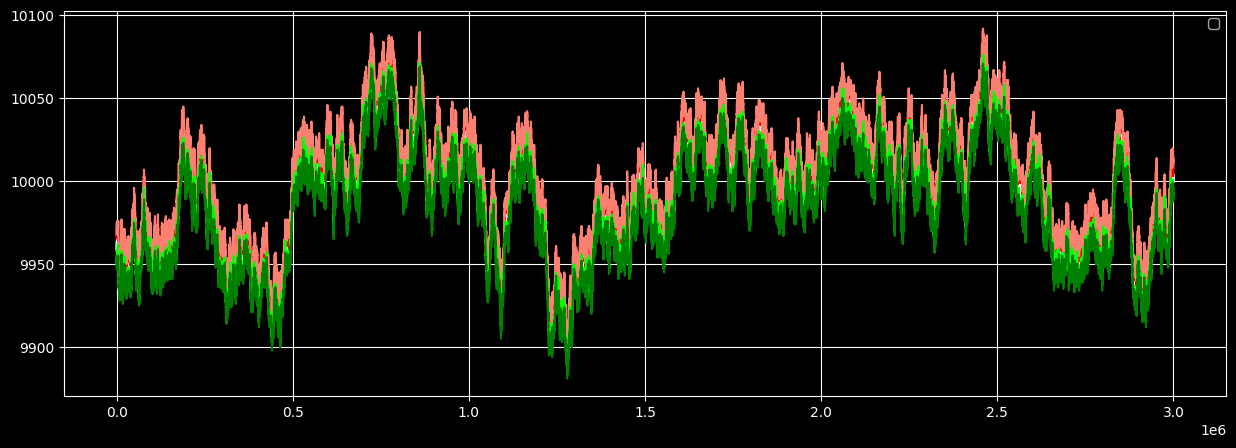

In [63]:
# PLOTS OF PRICES
plt.figure(figsize = (15,5))
plt.plot(hydrogel["t"], hydrogel["mid_price"], color = "white")
plt.plot(hydrogel["t"], hydrogel["ask_price_1"], color = "red")
plt.plot(hydrogel["t"], hydrogel["ask_price_2"], color = "salmon")
plt.plot(hydrogel["t"], hydrogel["bid_price_1"], color = "lime")
plt.plot(hydrogel["t"], hydrogel["bid_price_2"], color = "green")
plt.grid(True)
plt.legend()
plt.show()

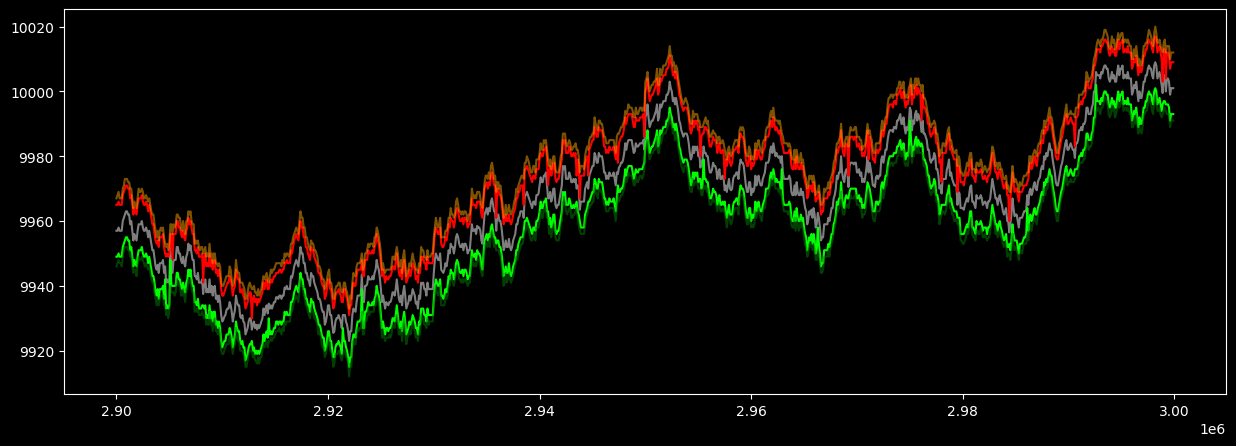

In [64]:
plt.figure(figsize=(15,5))
plt.plot(hydrogel["t"][-1000:], hydrogel["mid_price"][-1000:], color = "white", alpha = 0.5)
plt.plot(hydrogel["t"][-1000:], hydrogel["ask_price_1"][-1000:], color = "red", alpha = 1)
plt.plot(hydrogel["t"][-1000:], hydrogel["ask_price_2"][-1000:], color = "orange", alpha = 0.5)
plt.plot(hydrogel["t"][-1000:], hydrogel["ask_price_3"][-1000:], color = "salmon", alpha = 0.5)
plt.plot(hydrogel["t"][-1000:], hydrogel["bid_price_1"][-1000:], color = "lime", alpha = 1)
plt.plot(hydrogel["t"][-1000:], hydrogel["bid_price_2"][-1000:], color = "green", alpha = 0.5)
plt.plot(hydrogel["t"][-1000:], hydrogel["bid_price_3"][-1000:], color = "darkgreen", alpha = 0.5)
plt.show()

### KALMAN FILTER FV AND Z SCORE

In [65]:
def compute_max_vol_fv(df: pd.DataFrame, fast_window: int = 10) -> pd.DataFrame:
    df = df.copy()

    bid_prices  = df[["bid_price_1",  "bid_price_2",  "bid_price_3"]].values
    bid_volumes = df[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].values
    ask_prices  = df[["ask_price_1",  "ask_price_2",  "ask_price_3"]].values
    ask_volumes = df[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].values

    n = len(df)

    bid_all_nan = np.all(np.isnan(bid_volumes), axis=1)
    ask_all_nan = np.all(np.isnan(ask_volumes), axis=1)

    bid_argmax = np.where(bid_all_nan, 0, np.nanargmax(np.where(np.isnan(bid_volumes), -np.inf, bid_volumes), axis=1))
    ask_argmax = np.where(ask_all_nan, 0, np.nanargmax(np.where(np.isnan(ask_volumes), -np.inf, ask_volumes), axis=1))

    max_vol_bid = bid_prices[np.arange(n), bid_argmax]
    max_vol_ask = ask_prices[np.arange(n), ask_argmax]

    max_vol_bid = np.where(bid_all_nan, np.nan, max_vol_bid)
    max_vol_ask = np.where(ask_all_nan, np.nan, max_vol_ask)

    df["max_vol_bid"] = max_vol_bid
    df["max_vol_ask"] = max_vol_ask

    # Raw FV: midpoint; fall back to whichever side is present
    both_present = ~np.isnan(max_vol_bid) & ~np.isnan(max_vol_ask)
    only_bid     = ~np.isnan(max_vol_bid) &  np.isnan(max_vol_ask)
    only_ask     =  np.isnan(max_vol_bid) & ~np.isnan(max_vol_ask)

    raw_fv = np.where(both_present, (max_vol_bid + max_vol_ask) / 2,
             np.where(only_bid,     max_vol_bid,
             np.where(only_ask,     max_vol_ask, np.nan)))

    # Forward-fill the NaN (both absent) rows with the last valid value
    raw_fv_series = pd.Series(raw_fv).ffill()
    df["fv"] = raw_fv_series.values


    return df

hydrogel = compute_max_vol_fv(hydrogel, fast_window=10)
hydrogel[["max_vol_bid", "max_vol_ask", "fv"]].head(10)

,max_vol_bid,max_vol_ask,fv
0,9947.0,9968.0,9957.5
1,9950.0,9971.0,9960.5
2,9951.0,9972.0,9961.5
3,9950.0,9971.0,9960.5
4,9951.0,9972.0,9961.5
5,9952.0,9973.0,9962.5
6,9954.0,9975.0,9964.5
7,9954.0,9975.0,9964.5
8,9952.0,9973.0,9962.5
9,9951.0,9972.0,9961.5


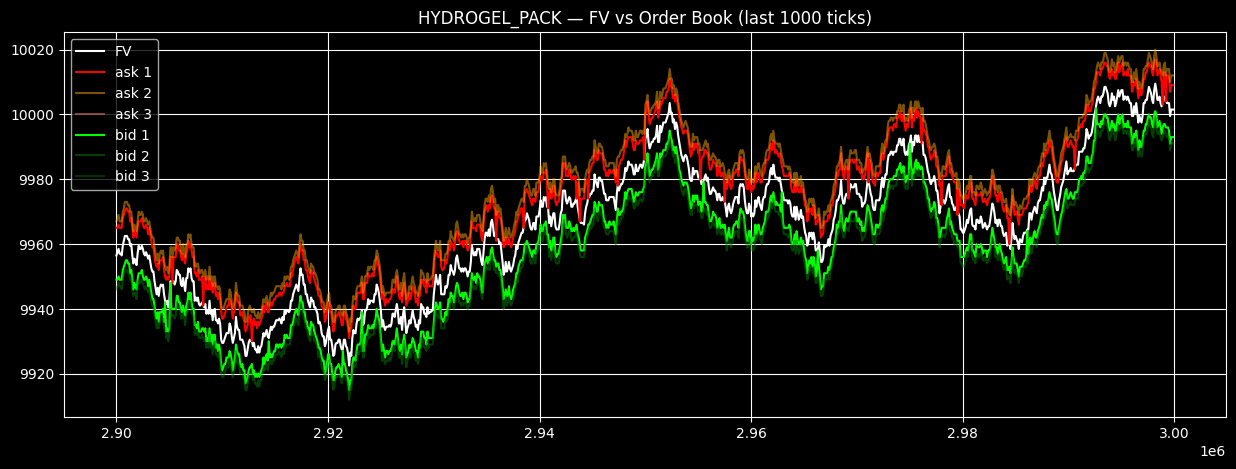

In [66]:
plt.figure(figsize=(15, 5))
plt.plot(hydrogel["t"][-1000:], hydrogel["fv"][-1000:],    color="white",  linewidth=1.5, label="FV")
plt.plot(hydrogel["t"][-1000:], hydrogel["ask_price_1"][-1000:], color="red",       alpha=1,   label="ask 1")
plt.plot(hydrogel["t"][-1000:], hydrogel["ask_price_2"][-1000:], color="orange",    alpha=0.5, label="ask 2")
plt.plot(hydrogel["t"][-1000:], hydrogel["ask_price_3"][-1000:], color="salmon",    alpha=0.5, label="ask 3")
plt.plot(hydrogel["t"][-1000:], hydrogel["bid_price_1"][-1000:], color="lime",      alpha=1,   label="bid 1")
plt.plot(hydrogel["t"][-1000:], hydrogel["bid_price_2"][-1000:], color="green",     alpha=0.5, label="bid 2")
plt.plot(hydrogel["t"][-1000:], hydrogel["bid_price_3"][-1000:], color="darkgreen", alpha=0.5, label="bid 3")
plt.legend()
plt.grid(True)
plt.title("HYDROGEL_PACK — FV vs Order Book (last 1000 ticks)")
plt.show()

In [84]:
# Z-Score of SMA-10 FV vs its 500-tick rolling SMA
WINDOW = 50
rolling_mean = hydrogel["fv"].rolling(window = WINDOW).mean()
std = hydrogel["fv"].rolling(window = WINDOW).std()

hydrogel["zscore"] = (hydrogel["fv"] - 9990) / std
hydrogel.tail(10000)

,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,...,market order price,market order quantity,buyer,seller,t,max_vol_bid,max_vol_ask,fv,zscore,rolling_vol
20000,HYDROGEL_PACK,10000,10,9998.0,25.0,NaN,NaN,10016,10,10019.0,...,NaN,NaN,NaN,NaN,2000000,9998.0,10019.0,10008.5,3.419423,1.802776
20001,HYDROGEL_PACK,10000,11,9997.0,28.0,NaN,NaN,10016,11,10018.0,...,NaN,NaN,NaN,NaN,2000100,9997.0,10018.0,10007.5,3.202267,1.794605
20002,HYDROGEL_PACK,10000,10,9997.0,20.0,NaN,NaN,10016,10,10018.0,...,NaN,NaN,NaN,NaN,2000200,9997.0,10018.0,10007.5,3.196680,1.794605
20003,HYDROGEL_PACK,9996,10,9994.0,20.0,NaN,NaN,10012,10,10015.0,...,NaN,NaN,NaN,NaN,2000300,9994.0,10015.0,10004.5,2.620282,1.815645
20004,HYDROGEL_PACK,9995,11,9993.0,30.0,NaN,NaN,10011,11,10014.0,...,NaN,NaN,NaN,NaN,2000400,9993.0,10014.0,10003.5,2.395285,1.814643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,HYDROGEL_PACK,9995,12,9993.0,22.0,NaN,NaN,10011,12,10014.0,...,NaN,NaN,NaN,NaN,2999500,9993.0,10014.0,10003.5,4.794916,1.775933
29996,HYDROGEL_PACK,9991,13,9989.0,29.0,NaN,NaN,10007,13,10010.0,...,NaN,NaN,NaN,NaN,2999600,9989.0,10010.0,9999.5,3.299608,1.816757
29997,HYDROGEL_PACK,9993,12,9991.0,20.0,NaN,NaN,10009,12,10012.0,...,NaN,NaN,NaN,NaN,2999700,9991.0,10012.0,10001.5,4.032568,1.816757
29998,HYDROGEL_PACK,9993,15,9991.0,22.0,NaN,NaN,10009,15,10012.0,...,NaN,NaN,NaN,NaN,2999800,9991.0,10012.0,10001.5,4.022085,1.807504


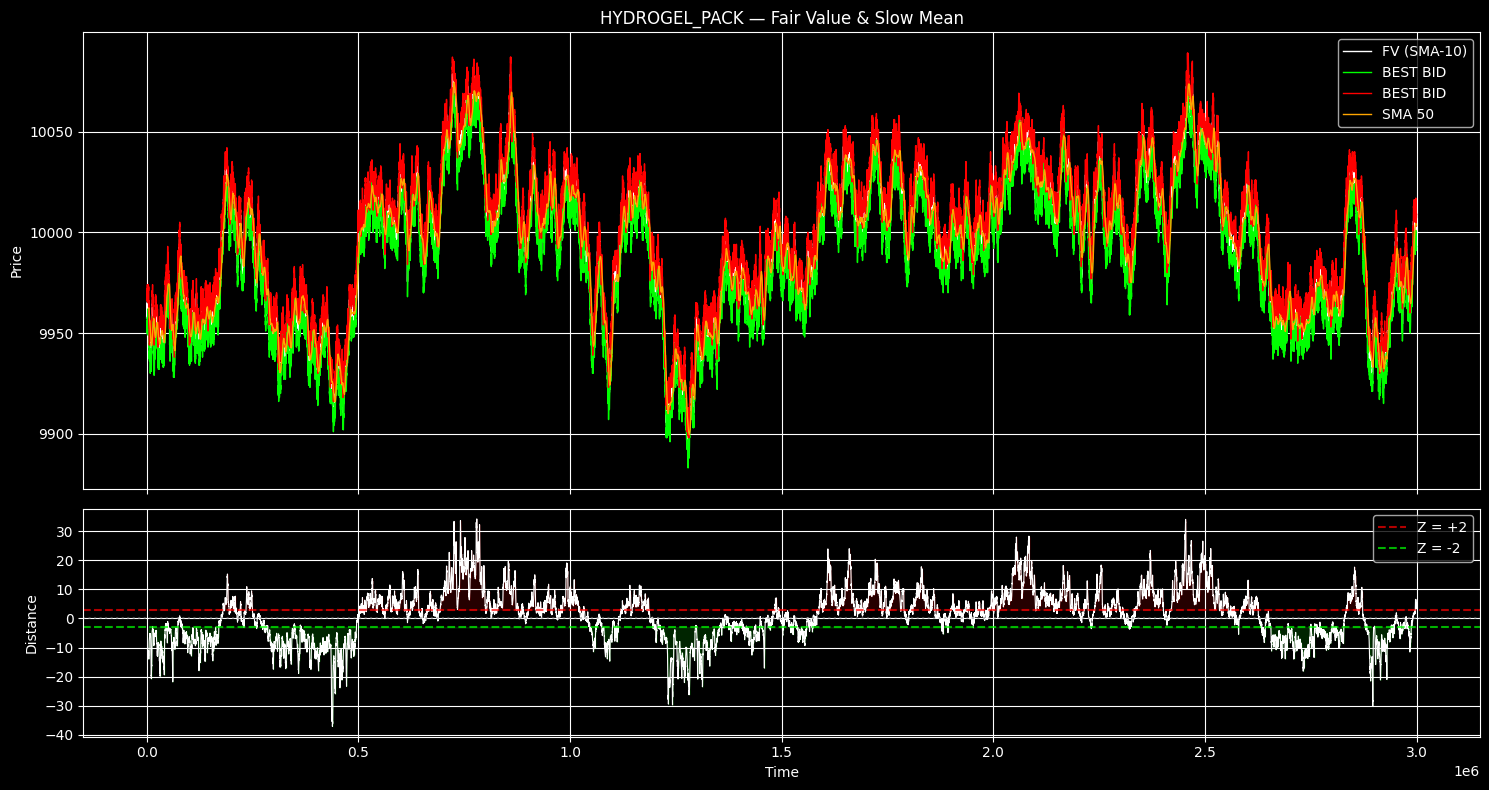

In [85]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(hydrogel["t"], hydrogel["fv"],   color="white",  linewidth=1,   label="FV (SMA-10)")
ax1.plot(hydrogel["t"], hydrogel["bid_price_1"], color="lime", linewidth = 1, label = "BEST BID")
ax1.plot(hydrogel["t"], hydrogel["ask_price_1"], color="red", linewidth = 1, label = "BEST BID")
ax1.plot(hydrogel["t"], rolling_mean,     color="orange", linewidth=1,   label=f"SMA {WINDOW}")
ax1.legend()
ax1.grid(True)
ax1.set_ylabel("Price")
ax1.set_title("HYDROGEL_PACK — Fair Value & Slow Mean")

ax2.plot(hydrogel["t"], hydrogel["zscore"], color="white", linewidth=0.8)
ax2.axhline( 3, color="red",  linestyle="--", alpha=0.7, label="Z = +2")
ax2.axhline(-3, color="lime", linestyle="--", alpha=0.7, label="Z = -2")
ax2.axhline( 0, color="gray", linestyle=":",  alpha=0.5)
ax2.fill_between(hydrogel["t"],  3, hydrogel["zscore"].clip(lower=3),  color="red",  alpha=0.15)
ax2.fill_between(hydrogel["t"], -3, hydrogel["zscore"].clip(upper=-3), color="lime", alpha=0.15)
ax2.set_ylabel("Distance")
ax2.set_xlabel("Time")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

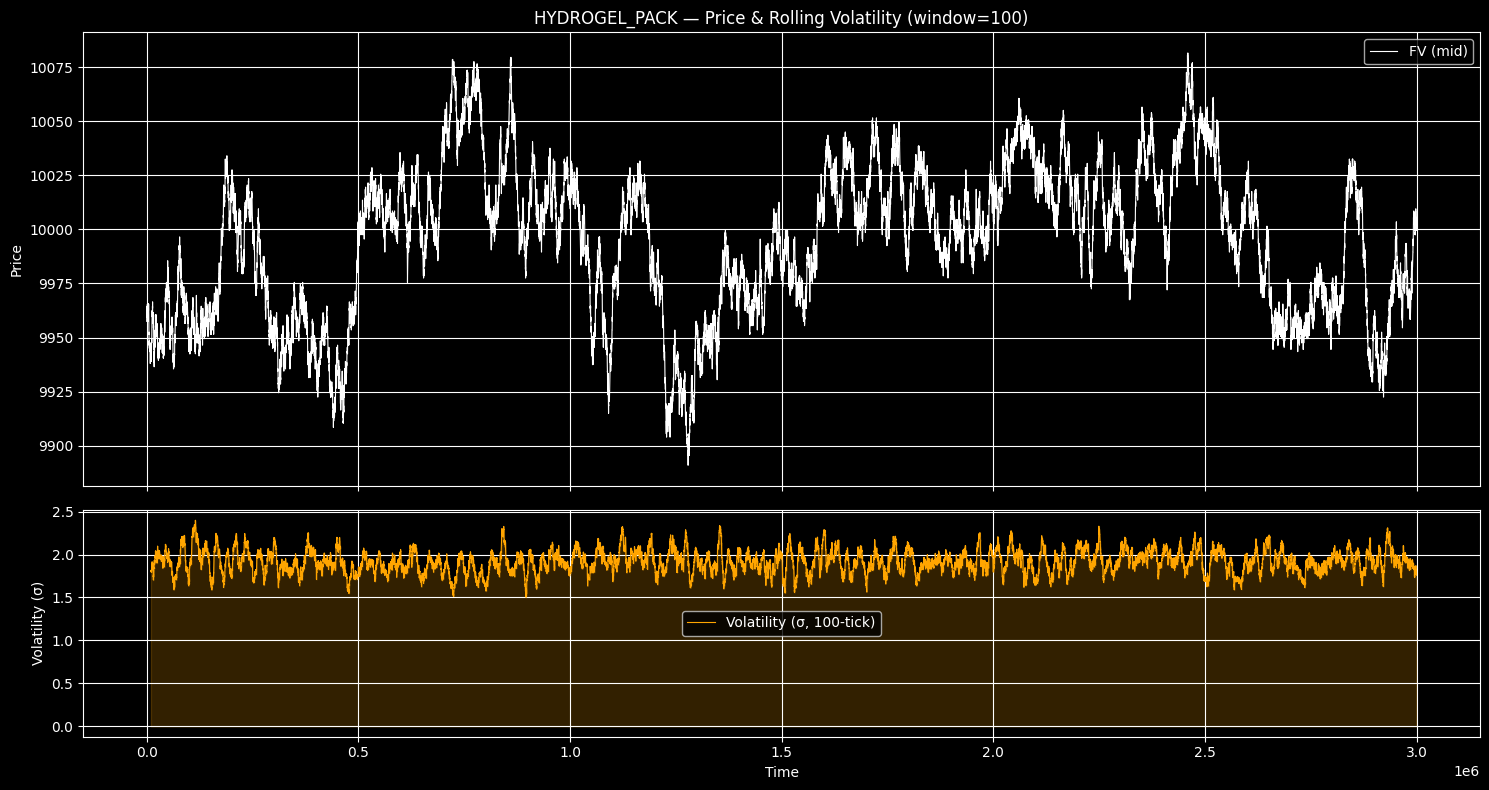

Mean vol : 1.9191
Max vol  : 2.3985
Std vol  : 0.1332


In [73]:
# Price and rolling 10-tick volatility
VOL_WINDOW = 100
hydrogel["rolling_vol"] = hydrogel["fv"].diff().rolling(window=VOL_WINDOW).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(hydrogel["t"], hydrogel["fv"], color="white", linewidth=0.8, label="FV (mid)")
ax1.set_ylabel("Price")
ax1.set_title(f"HYDROGEL_PACK — Price & Rolling Volatility (window={VOL_WINDOW})")
ax1.legend()
ax1.grid(True)

ax2.plot(hydrogel["t"], hydrogel["rolling_vol"], color="orange", linewidth=0.8, label=f"Volatility (σ, {VOL_WINDOW}-tick)")
ax2.fill_between(hydrogel["t"], 0, hydrogel["rolling_vol"], color="orange", alpha=0.2)
ax2.set_ylabel("Volatility (σ)")
ax2.set_xlabel("Time")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Mean vol : {hydrogel['rolling_vol'].mean():.4f}")
print(f"Max vol  : {hydrogel['rolling_vol'].max():.4f}")
print(f"Std vol  : {hydrogel['rolling_vol'].std():.4f}")

In [ ]:
# ── Per-bot trades: entries/exits colored by volume, equity line, stats ───────
hyd_raw_plot = trades_df[trades_df["symbol"] == SYMBOL].copy()
hyd_raw_plot = hyd_raw_plot.dropna(subset=["buyer", "seller"])
hyd_raw_plot["t"] = (
    hyd_raw_plot["day"].map({1: 0, 2: 1_000_000, 3: 2_000_000})
    + hyd_raw_plot["timestamp"]
)

all_participants = sorted(
    set(hyd_raw_plot["buyer"].unique()) | set(hyd_raw_plot["seller"].unique())
)

# Volume colormap — shared scale across all traders
vol_min = hyd_raw_plot["quantity"].min()
vol_max = hyd_raw_plot["quantity"].max()
cmap    = plt.cm.plasma
norm    = plt.Normalize(vmin=vol_min, vmax=vol_max)

# Mark price for MTM PnL — deduplicate t so nearest-lookup works
mark_series = hydrogel.groupby("t")["mid_price"].last()

def get_mark(t):
    idx = mark_series.index.get_indexer([t], method="nearest")[0]
    return mark_series.iloc[idx]

def build_equity(trader: str) -> pd.DataFrame:
    buys  = hyd_raw_plot[hyd_raw_plot["buyer"]  == trader][["t", "price", "quantity"]].copy()
    sells = hyd_raw_plot[hyd_raw_plot["seller"] == trader][["t", "price", "quantity"]].copy()
    buys["side"]  =  1
    sells["side"] = -1
    df = pd.concat([buys, sells]).sort_values("t").reset_index(drop=True)
    df["cum_pos"]  = (df["side"] * df["quantity"]).cumsum()
    df["cum_cash"] = (-df["side"] * df["price"] * df["quantity"]).cumsum()
    df["mark"]     = df["t"].apply(get_mark)
    df["pnl"]      = df["cum_cash"] + df["cum_pos"] * df["mark"]
    return df

# ── One figure per trader ─────────────────────────────────────────────────────
for trader in all_participants:
    df        = build_equity(trader)
    buys      = df[df["side"] ==  1]
    sells     = df[df["side"] == -1]
    final_pnl = df["pnl"].iloc[-1]
    final_pos = int(df["cum_pos"].iloc[-1])

    fig = plt.figure(figsize=(16, 15))
    gs  = gridspec.GridSpec(4, 1, figure=fig,
                            height_ratios=[3, 1.8, 1.4, 0.9], hspace=0.35)
    ax_price     = fig.add_subplot(gs[0])
    ax_equity    = fig.add_subplot(gs[1], sharex=ax_price)
    ax_inventory = fig.add_subplot(gs[2], sharex=ax_price)
    ax_stats     = fig.add_subplot(gs[3])

    fig.suptitle(
        f"{trader}  —  {SYMBOL}  |  "
        f"Buys: {len(buys)}  Sells: {len(sells)}  |  "
        f"Final PnL: {final_pnl:+.1f}",
        fontsize=13
    )

    # ── Panel 1: price backdrop + entries/exits ───────────────────────────────
    ax_price.plot(mark_series.index, mark_series.values,
                  color="white", linewidth=0.7, alpha=0.35, label="Mid price")

    if len(buys):
        ax_price.scatter(buys["t"], buys["price"],
                         c=buys["quantity"], cmap=cmap, norm=norm,
                         s=buys["quantity"] * 16, marker="^",
                         alpha=0.95, zorder=4, label="Buy  ▲")
    if len(sells):
        ax_price.scatter(sells["t"], sells["price"],
                         c=sells["quantity"], cmap=cmap, norm=norm,
                         s=sells["quantity"] * 16, marker="v",
                         alpha=0.95, zorder=4, label="Sell ▽",
                         edgecolors="white", linewidths=0.4)

    # Annotate size next to each marker
    for _, row in df.iterrows():
        ax_price.annotate(
            str(int(row["quantity"])),
            xy=(row["t"], row["price"]),
            xytext=(0, 10 if row["side"] == 1 else -14),
            textcoords="offset points",
            ha="center", fontsize=7,
            color=cmap(norm(row["quantity"]))
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_price, pad=0.01, shrink=0.85, label="Order size")
    cbar.ax.yaxis.label.set_color("white")
    cbar.ax.tick_params(colors="white")

    ax_price.set_ylabel("Price")
    ax_price.legend(fontsize=8, loc="upper left")
    ax_price.grid(True, alpha=0.3)

    # ── Panel 2: equity line ──────────────────────────────────────────────────
    ax_equity.plot(df["t"], df["pnl"], color="gold", linewidth=1.4, label="MTM PnL")
    ax_equity.axhline(0, color="gray", linestyle=":", alpha=0.5)
    ax_equity.fill_between(df["t"], 0, df["pnl"],
                           where=(df["pnl"] >= 0), color="lime", alpha=0.18)
    ax_equity.fill_between(df["t"], 0, df["pnl"],
                           where=(df["pnl"] <  0), color="red",  alpha=0.18)
    ax_equity.scatter(df["t"].iloc[-1], final_pnl,
                      color="gold", s=70, zorder=5,
                      label=f"Final  {final_pnl:+.1f}")
    ax_equity.set_ylabel("PnL")
    ax_equity.legend(fontsize=8)
    ax_equity.grid(True, alpha=0.3)

    # ── Panel 3: inventory ────────────────────────────────────────────────────
    ax_inventory.step(df["t"], df["cum_pos"], where="post",
                      color="cyan", linewidth=1.2, label="Inventory")
    ax_inventory.axhline(0, color="gray", linestyle=":", alpha=0.5)
    ax_inventory.fill_between(df["t"], 0, df["cum_pos"],
                              where=(df["cum_pos"] > 0), color="cyan", alpha=0.15,
                              step="post")
    ax_inventory.fill_between(df["t"], 0, df["cum_pos"],
                              where=(df["cum_pos"] < 0), color="magenta", alpha=0.15,
                              step="post")
    ax_inventory.scatter(df["t"].iloc[-1], final_pos,
                         color="cyan", s=70, zorder=5,
                         label=f"Final  {final_pos:+d}")
    ax_inventory.set_ylabel("Inventory")
    ax_inventory.set_xlabel("Time")
    ax_inventory.legend(fontsize=8)
    ax_inventory.grid(True, alpha=0.3)

    # ── Panel 4: stats table ──────────────────────────────────────────────────
    ax_stats.axis("off")

    stat_keys = ["Trades", "Buys", "Sells", "Total vol",
                 "Avg size", "Max order", "Avg buy px", "Avg sell px",
                 "Final pos", "Final PnL", "Max PnL", "Min PnL"]
    stat_vals = [
        len(df),
        len(buys),
        len(sells),
        int(df["quantity"].sum()),
        f"{df['quantity'].mean():.1f}",
        int(df["quantity"].max()),
        f"{buys['price'].mean():.1f}"  if len(buys)  else "—",
        f"{sells['price'].mean():.1f}" if len(sells) else "—",
        final_pos,
        f"{final_pnl:+.1f}",
        f"{df['pnl'].max():+.1f}",
        f"{df['pnl'].min():+.1f}",
    ]

    tbl = ax_stats.table(
        cellText=[list(map(str, stat_vals))],
        colLabels=stat_keys,
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1, 2.2)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_facecolor("#111111" if r == 0 else "#1e1e1e")
        cell.set_edgecolor("#3a3a3a")
        cell.set_text_props(color="white")

    plt.show()

---
## Returns Analysis

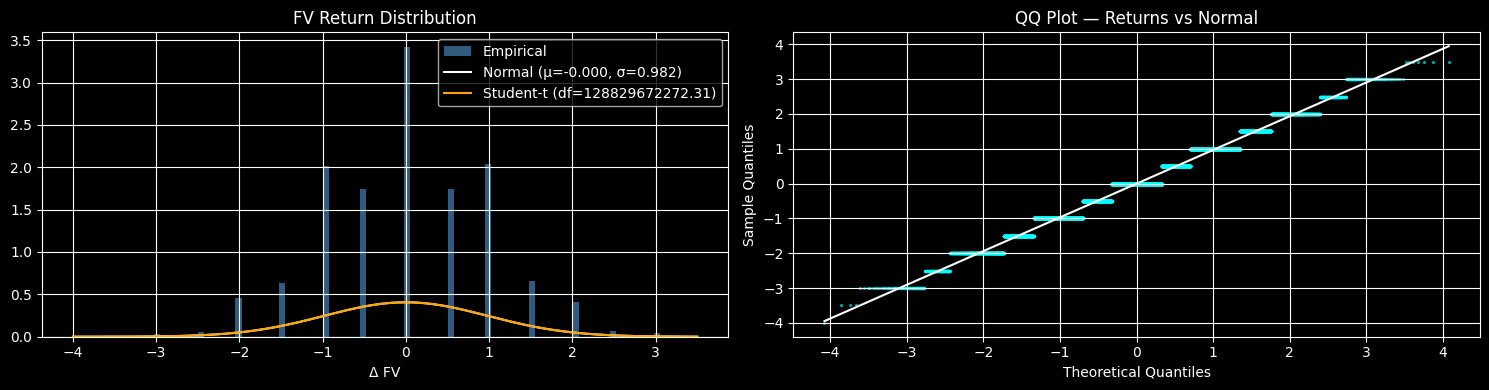

Mean   : -0.0004
Std    : 0.9819
Skew   : 0.0019
Kurt   : -0.0494  (excess)

Jarque-Bera stat : 3.10  p-value : 0.2124
→ Returns are normally distributed at 5% level


In [16]:
# Tick-by-tick price changes on the fair value
hydrogel["fv_return"] = hydrogel["fv"].diff()
returns = hydrogel["fv_return"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Histogram with fitted normal and t-distribution
ax = axes[0]
ax.hist(returns, bins=100, density=True, color="steelblue", alpha=0.7, label="Empirical")

x = np.linspace(returns.min(), returns.max(), 500)

mu, sigma = stats.norm.fit(returns)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color="white", linewidth=1.5, label=f"Normal (μ={mu:.3f}, σ={sigma:.3f})")

df_t, loc_t, scale_t = stats.t.fit(returns)
ax.plot(x, stats.t.pdf(x, df_t, loc_t, scale_t), color="orange", linewidth=1.5, label=f"Student-t (df={df_t:.2f})")

ax.set_title("FV Return Distribution")
ax.set_xlabel("Δ FV")
ax.legend()
ax.grid(True)

# QQ plot vs normal
ax = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(returns, dist="norm")
ax.scatter(osm, osr, s=2, color="cyan", alpha=0.5)
ax.plot(osm, slope * np.array(osm) + intercept, color="white", linewidth=1.5)
ax.set_title("QQ Plot — Returns vs Normal")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles")
ax.grid(True)

plt.tight_layout()
plt.show()

print(f"Mean   : {returns.mean():.4f}")
print(f"Std    : {returns.std():.4f}")
print(f"Skew   : {returns.skew():.4f}")
print(f"Kurt   : {returns.kurtosis():.4f}  (excess)")

jb_stat, jb_p, skew_jb, kurt_jb = jarque_bera(returns)
print(f"\nJarque-Bera stat : {jb_stat:.2f}  p-value : {jb_p:.4f}")
print("→ Returns are " + ("NOT " if jb_p < 0.05 else "") + "normally distributed at 5% level")

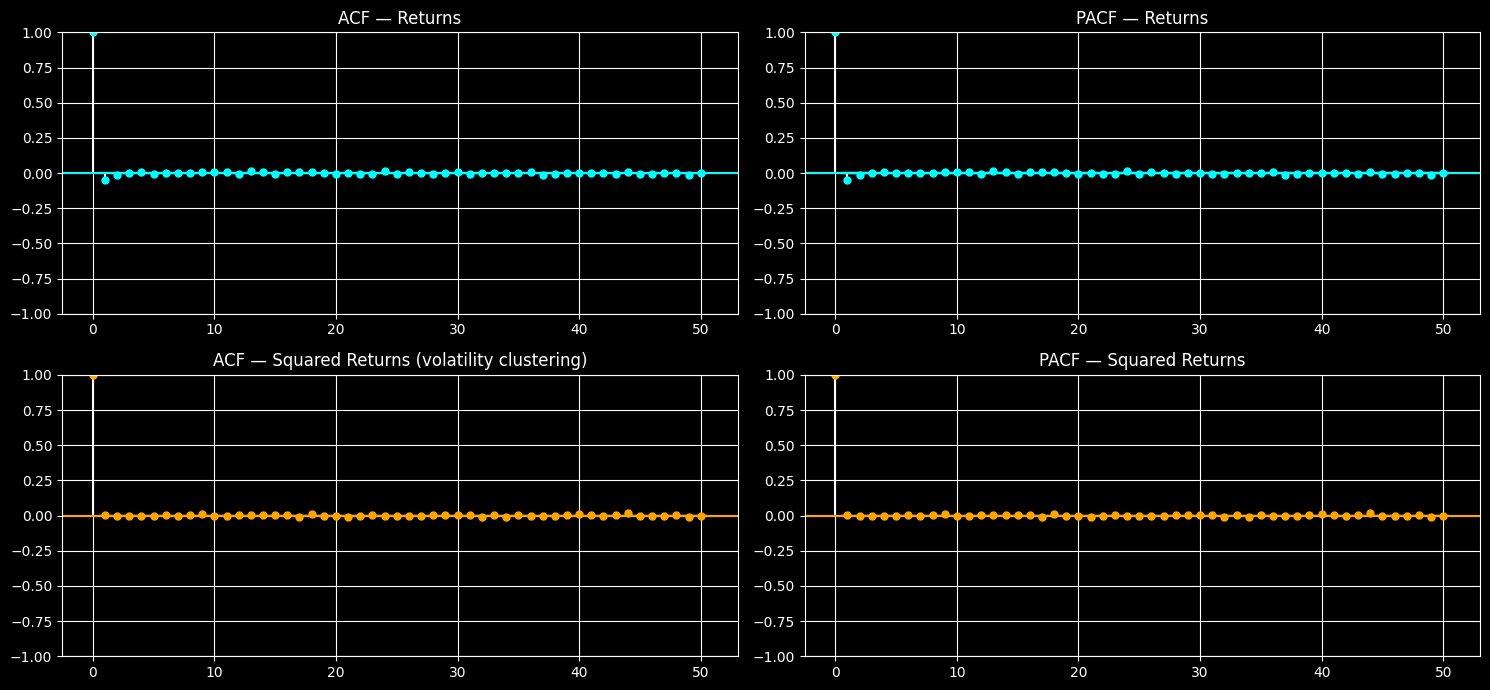

In [17]:
# ACF / PACF of returns and squared returns (volatility clustering check)
fig, axes = plt.subplots(2, 2, figsize=(15, 7))

plot_acf (returns,           ax=axes[0, 0], lags=50, color="cyan",   title="ACF — Returns")
plot_pacf(returns,           ax=axes[0, 1], lags=50, color="cyan",   title="PACF — Returns", method="ywm")
plot_acf (returns ** 2,      ax=axes[1, 0], lags=50, color="orange", title="ACF — Squared Returns (volatility clustering)")
plot_pacf(returns ** 2,      ax=axes[1, 1], lags=50, color="orange", title="PACF — Squared Returns", method="ywm")

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()

In [18]:
# ADF stationarity tests
for series_name, series in [("FV (mid)", hydrogel["fv"]), ("FV Returns", returns)]:
    result = adfuller(series.dropna())
    print(f"--- {series_name} ---")
    print(f"  ADF stat : {result[0]:.4f}")
    print(f"  p-value  : {result[1]:.4f}")
    print(f"  {'Stationary ✓' if result[1] < 0.05 else 'Non-stationary ✗'} at 5% level\n")

--- FV (mid) ---
  ADF stat : -4.3842
  p-value  : 0.0003
  Stationary ✓ at 5% level

--- FV Returns ---
  ADF stat : -127.2263
  p-value  : 0.0000
  Stationary ✓ at 5% level



---
## Distance Strategy Backtest

In [19]:
BT_SMA_WINDOW  = 100
BT_THRESHOLD   = 15

bt = hydrogel[["t", "fv"]].copy().dropna().reset_index(drop=True)
bt["sma"]      = bt["fv"].rolling(BT_SMA_WINDOW, min_periods=1).mean()
bt["distance"] = bt["fv"] - bt["sma"]

# State machine: enter short on dist > threshold, exit when dist < 0; opposite for long
pos, positions = 0, []
for d in bt["distance"]:
    if d > BT_THRESHOLD:
        pos = -1
    elif d < -BT_THRESHOLD:
        pos = 1
    elif d < 0 and pos == -1:
        pos = 0
    elif d > 0 and pos == 1:
        pos = 0
    positions.append(pos)

bt["position"]     = positions
bt["fv_chg"]       = bt["fv"].diff()
bt["strat_pnl"]    = bt["position"].shift(1) * bt["fv_chg"]
bt["cum_pnl"]      = bt["strat_pnl"].cumsum()
bt["bh_pnl"]       = bt["fv_chg"].cumsum()   # buy-and-hold baseline

total_pnl   = bt["cum_pnl"].iloc[-1]
n_trades    = (bt["position"].diff().abs() > 0).sum()
sharpe_raw  = bt["strat_pnl"].mean() / bt["strat_pnl"].std() * np.sqrt(len(bt))

print(f"Total PnL   : {total_pnl:.2f}")
print(f"Num signals : {n_trades}")
print(f"Sharpe (raw): {sharpe_raw:.3f}")
print(f"Time in mkt : {100*(bt['position'] != 0).mean():.1f}%")

Total PnL   : 61.50
Num signals : 34
Sharpe (raw): 1.754
Time in mkt : 4.1%


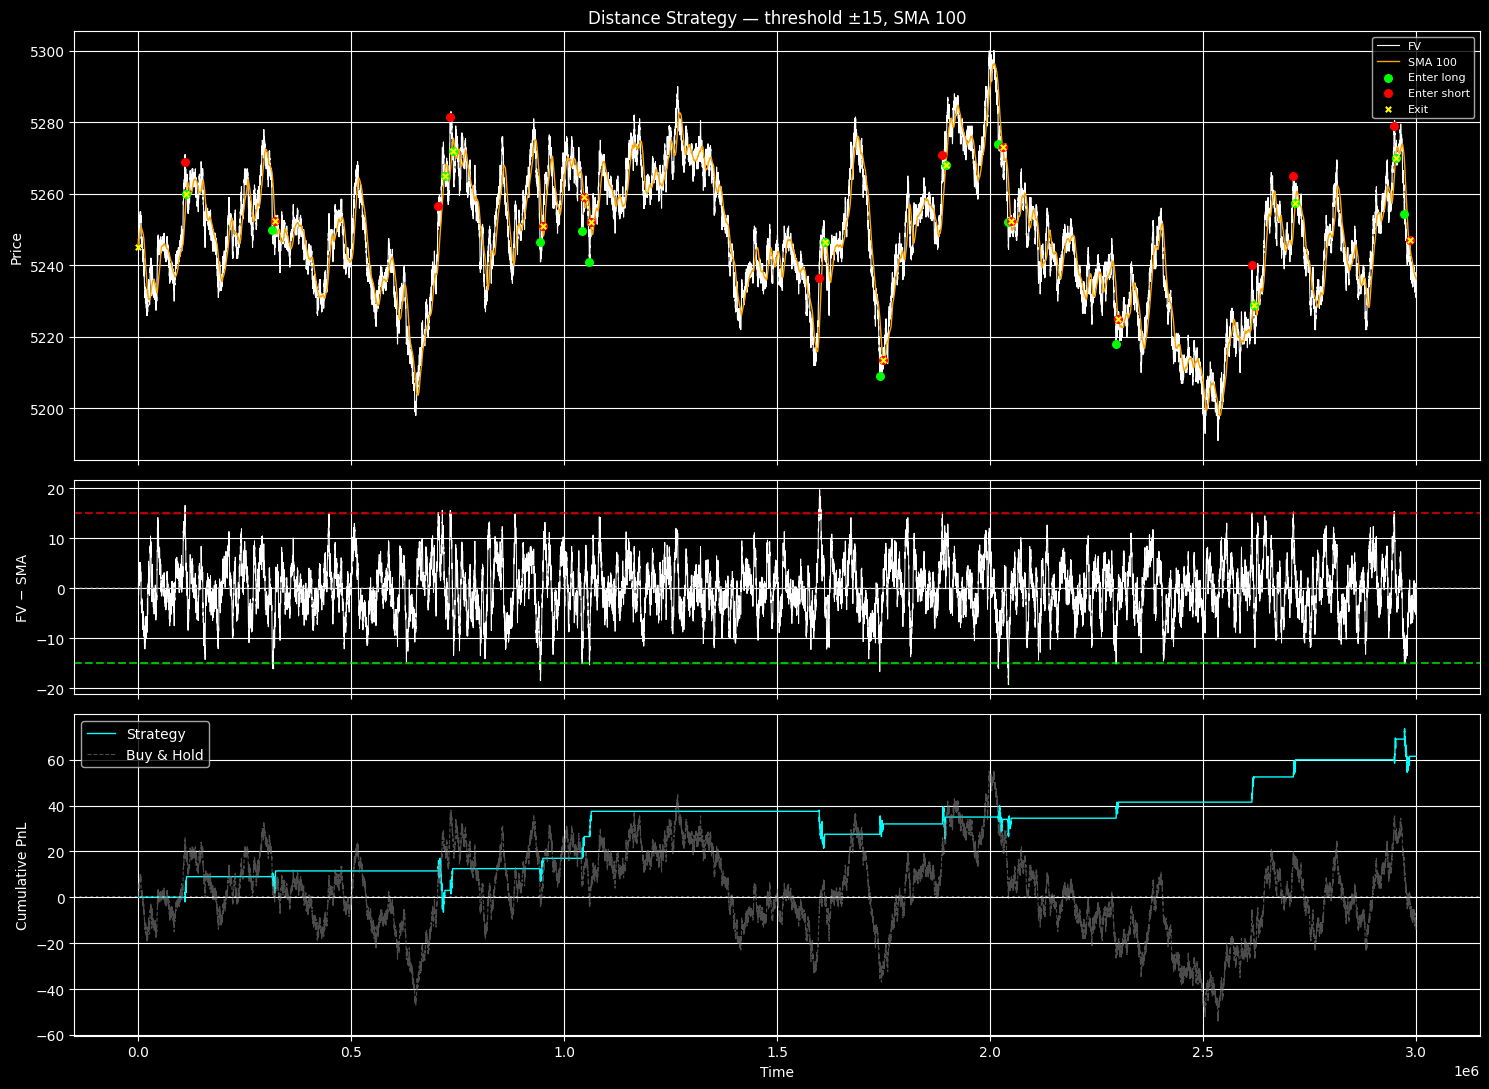

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1, 1.5]})

# Price + SMA + entry signals
long_entries  = bt[bt["position"].diff() ==  1]
short_entries = bt[bt["position"].diff() == -1]
exits         = bt[(bt["position"].diff() != 0) & (bt["position"] == 0)]

axes[0].plot(bt["t"], bt["fv"],  color="white",  linewidth=0.8, label="FV")
axes[0].plot(bt["t"], bt["sma"], color="orange", linewidth=1,   label=f"SMA {BT_SMA_WINDOW}")
axes[0].scatter(long_entries["t"],  long_entries["fv"],  color="lime",    s=30, zorder=5, label="Enter long")
axes[0].scatter(short_entries["t"], short_entries["fv"], color="red",     s=30, zorder=5, label="Enter short")
axes[0].scatter(exits["t"],         exits["fv"],         color="yellow",  s=15, zorder=5, marker="x", label="Exit")
axes[0].set_ylabel("Price")
axes[0].set_title(f"Distance Strategy — threshold ±{BT_THRESHOLD}, SMA {BT_SMA_WINDOW}")
axes[0].legend(fontsize=8)
axes[0].grid(True)

# Distance
axes[1].plot(bt["t"], bt["distance"], color="white", linewidth=0.7)
axes[1].axhline( BT_THRESHOLD, color="red",  linestyle="--", alpha=0.7)
axes[1].axhline(-BT_THRESHOLD, color="lime", linestyle="--", alpha=0.7)
axes[1].axhline(0,              color="gray", linestyle=":",  alpha=0.5)
axes[1].fill_between(bt["t"],  BT_THRESHOLD, bt["distance"].clip(lower= BT_THRESHOLD), color="red",  alpha=0.2)
axes[1].fill_between(bt["t"], -BT_THRESHOLD, bt["distance"].clip(upper=-BT_THRESHOLD), color="lime", alpha=0.2)
axes[1].set_ylabel("FV − SMA")
axes[1].grid(True)

# Cumulative PnL vs buy-and-hold
axes[2].plot(bt["t"], bt["cum_pnl"], color="cyan",   linewidth=1,   label="Strategy")
axes[2].plot(bt["t"], bt["bh_pnl"], color="gray",   linewidth=0.8, linestyle="--", alpha=0.6, label="Buy & Hold")
axes[2].axhline(0, color="white", linestyle=":", alpha=0.4)
axes[2].set_ylabel("Cumulative PnL")
axes[2].set_xlabel("Time")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

---
## Spread & Volume Imbalance Analysis

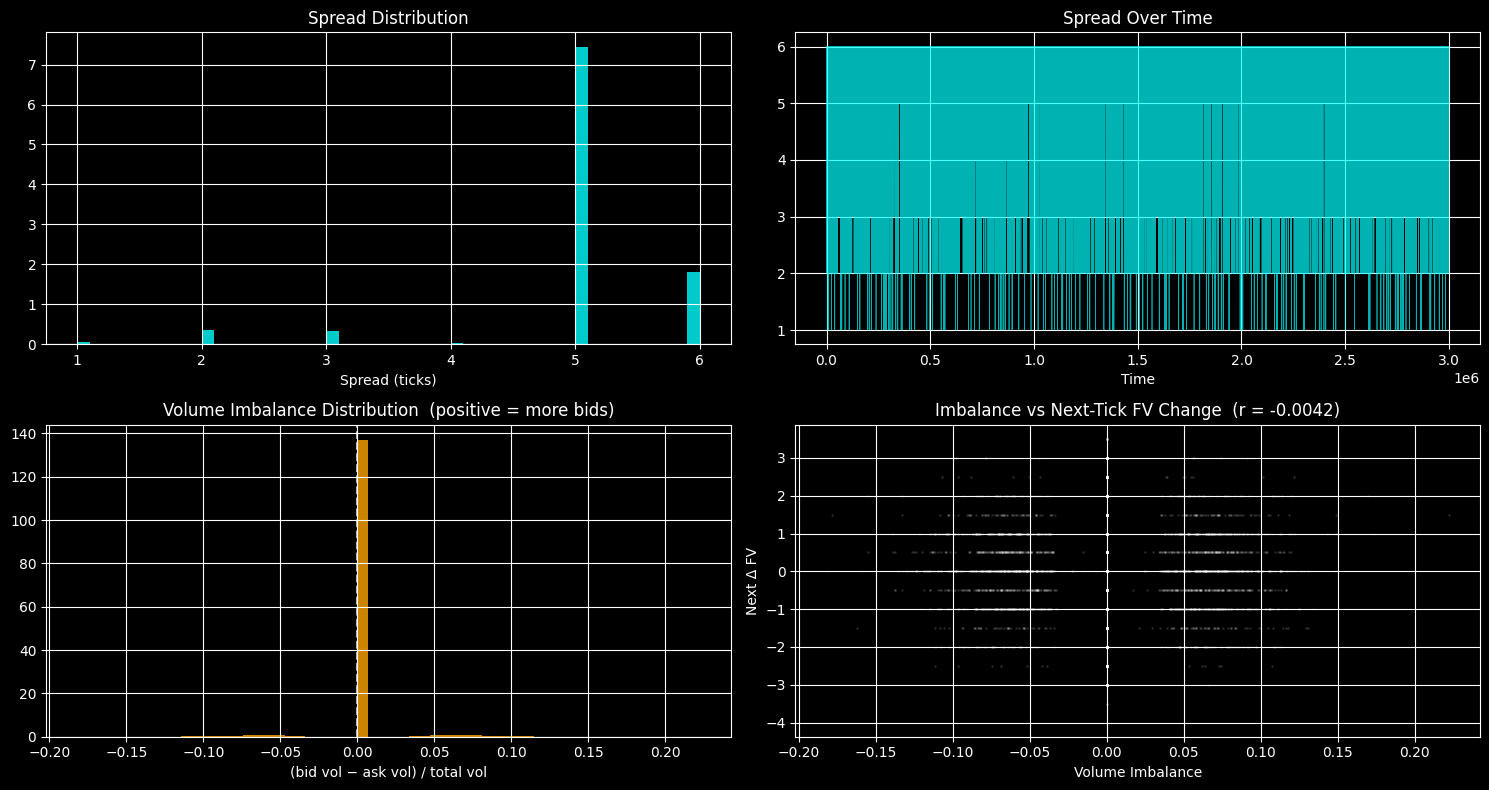

Spread — mean: 4.98  std: 0.85  min: 1  max: 6
Vol imbalance vs next return corr: -0.0042


In [21]:
# Spread distribution and volume imbalance
hydrogel["spread"] = hydrogel["ask_price_1"] - hydrogel["bid_price_1"]

total_bid_vol = hydrogel[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].sum(axis=1)
total_ask_vol = hydrogel[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].sum(axis=1)
hydrogel["vol_imbalance"] = (total_bid_vol - total_ask_vol) / (total_bid_vol + total_ask_vol)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Spread histogram
axes[0, 0].hist(hydrogel["spread"].dropna(), bins=50, color="cyan", alpha=0.8, density=True)
axes[0, 0].set_title("Spread Distribution")
axes[0, 0].set_xlabel("Spread (ticks)")
axes[0, 0].grid(True)

# Spread over time
axes[0, 1].plot(hydrogel["t"], hydrogel["spread"], color="cyan", linewidth=0.5, alpha=0.7)
axes[0, 1].set_title("Spread Over Time")
axes[0, 1].set_xlabel("Time")
axes[0, 1].grid(True)

# Volume imbalance distribution
axes[1, 0].hist(hydrogel["vol_imbalance"].dropna(), bins=60, color="orange", alpha=0.8, density=True)
axes[1, 0].axvline(0, color="white", linestyle="--", alpha=0.7)
axes[1, 0].set_title("Volume Imbalance Distribution  (positive = more bids)")
axes[1, 0].set_xlabel("(bid vol − ask vol) / total vol")
axes[1, 0].grid(True)

# Imbalance vs next-tick return (predictive power check)
hydrogel["next_fv_chg"] = hydrogel["fv"].diff().shift(-1)
imb_corr = hydrogel["vol_imbalance"].corr(hydrogel["next_fv_chg"])
axes[1, 1].scatter(hydrogel["vol_imbalance"], hydrogel["next_fv_chg"], s=1, alpha=0.1, color="white")
axes[1, 1].set_title(f"Imbalance vs Next-Tick FV Change  (r = {imb_corr:.4f})")
axes[1, 1].set_xlabel("Volume Imbalance")
axes[1, 1].set_ylabel("Next Δ FV")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print(f"Spread — mean: {hydrogel['spread'].mean():.2f}  std: {hydrogel['spread'].std():.2f}  min: {hydrogel['spread'].min():.0f}  max: {hydrogel['spread'].max():.0f}")
print(f"Vol imbalance vs next return corr: {imb_corr:.4f}")

---
## Market Participant Analysis — Entry, Exit & PnL

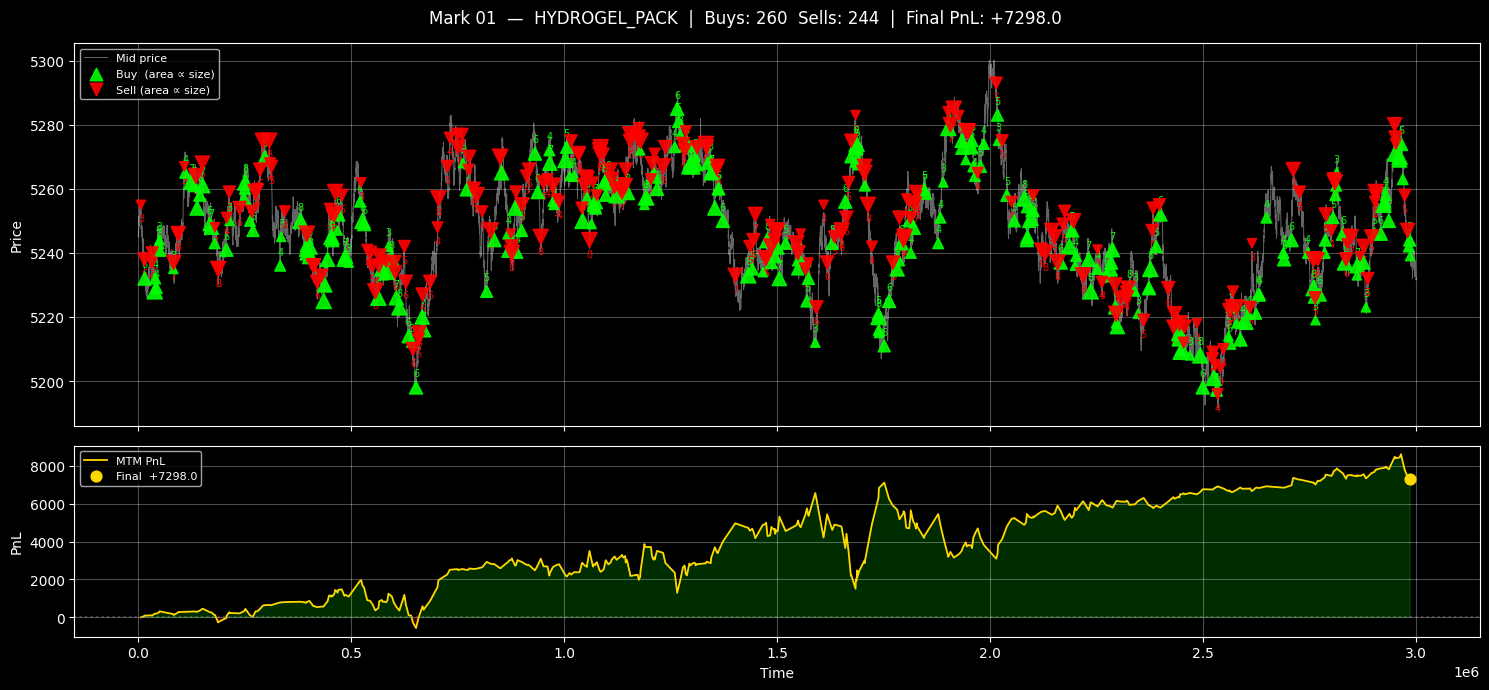

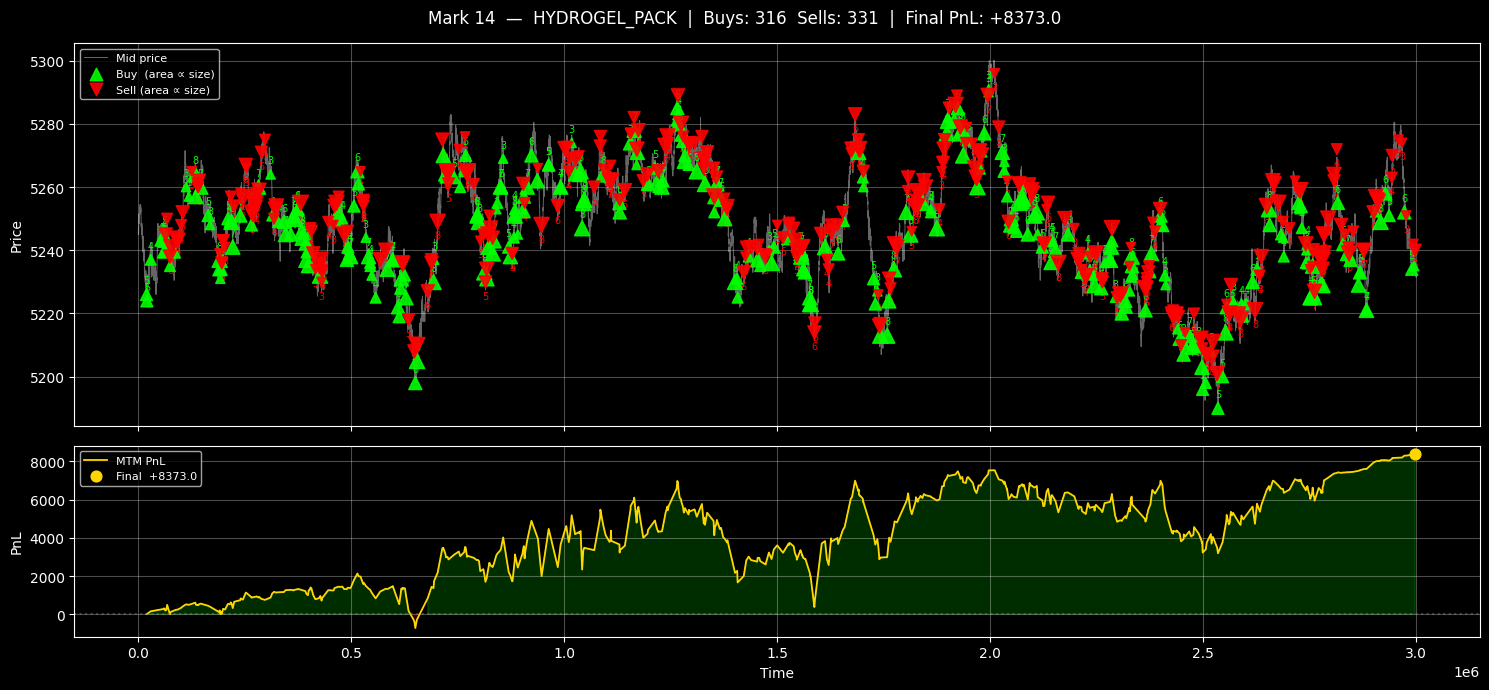

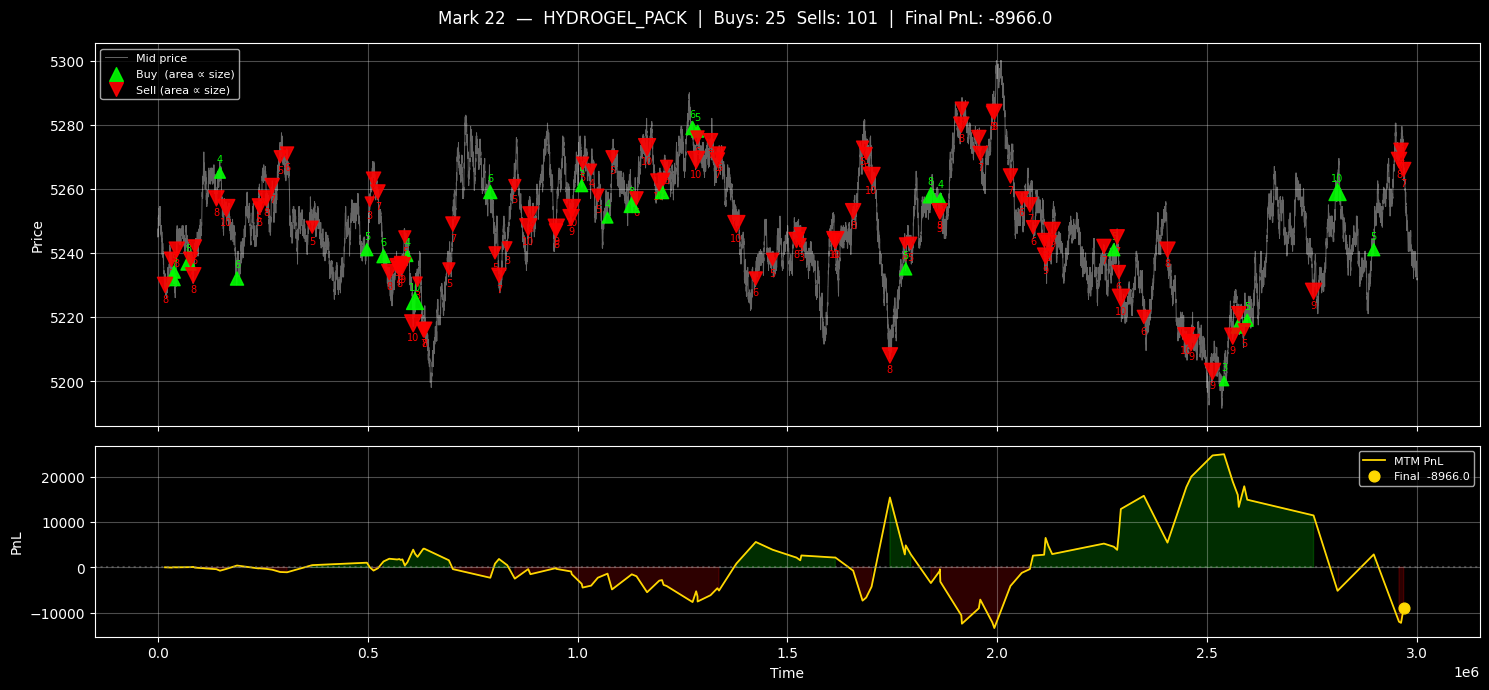

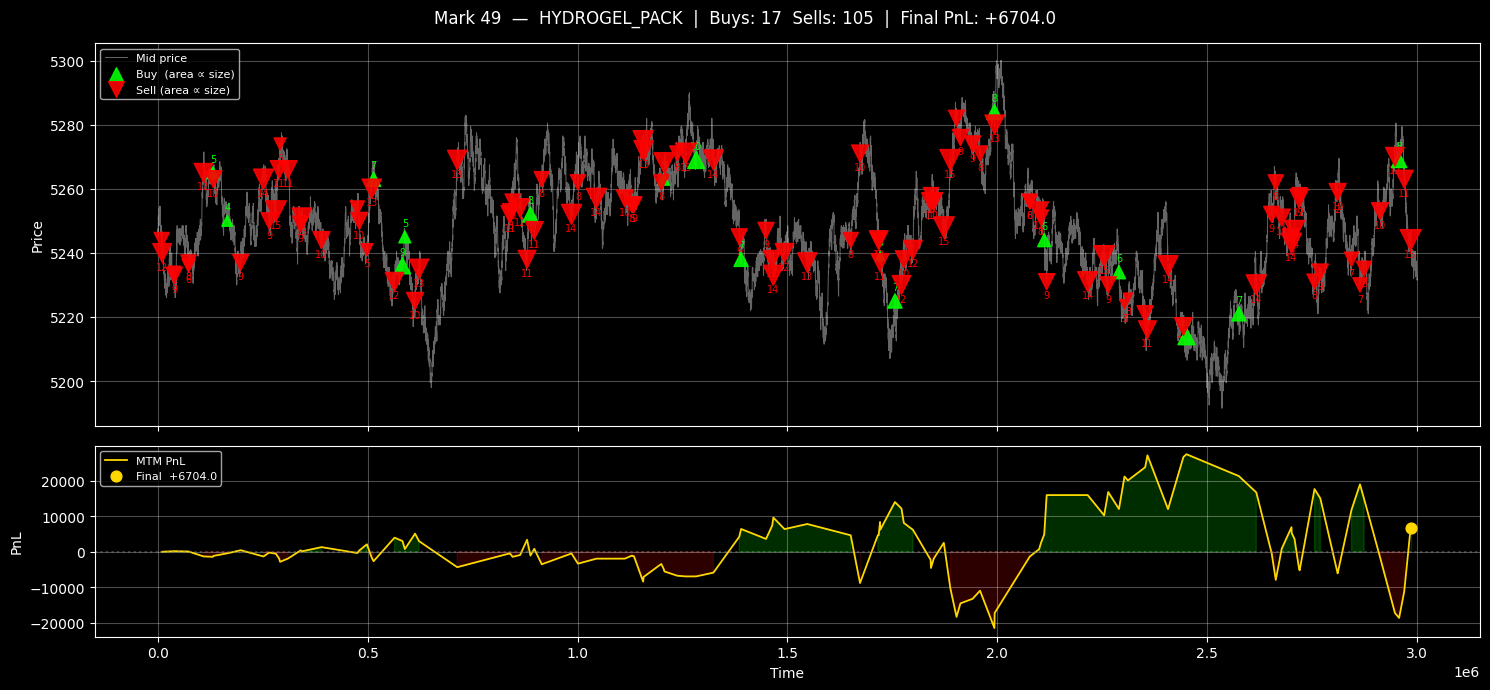

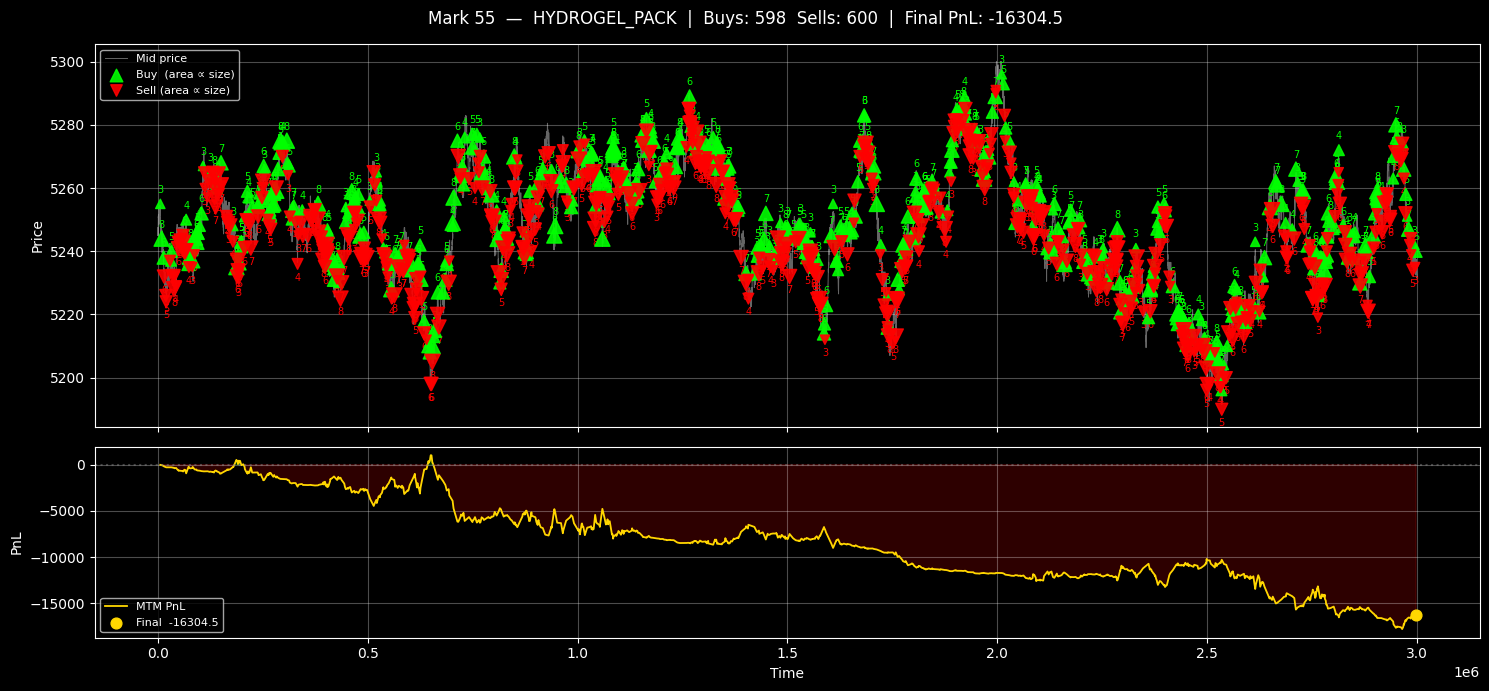

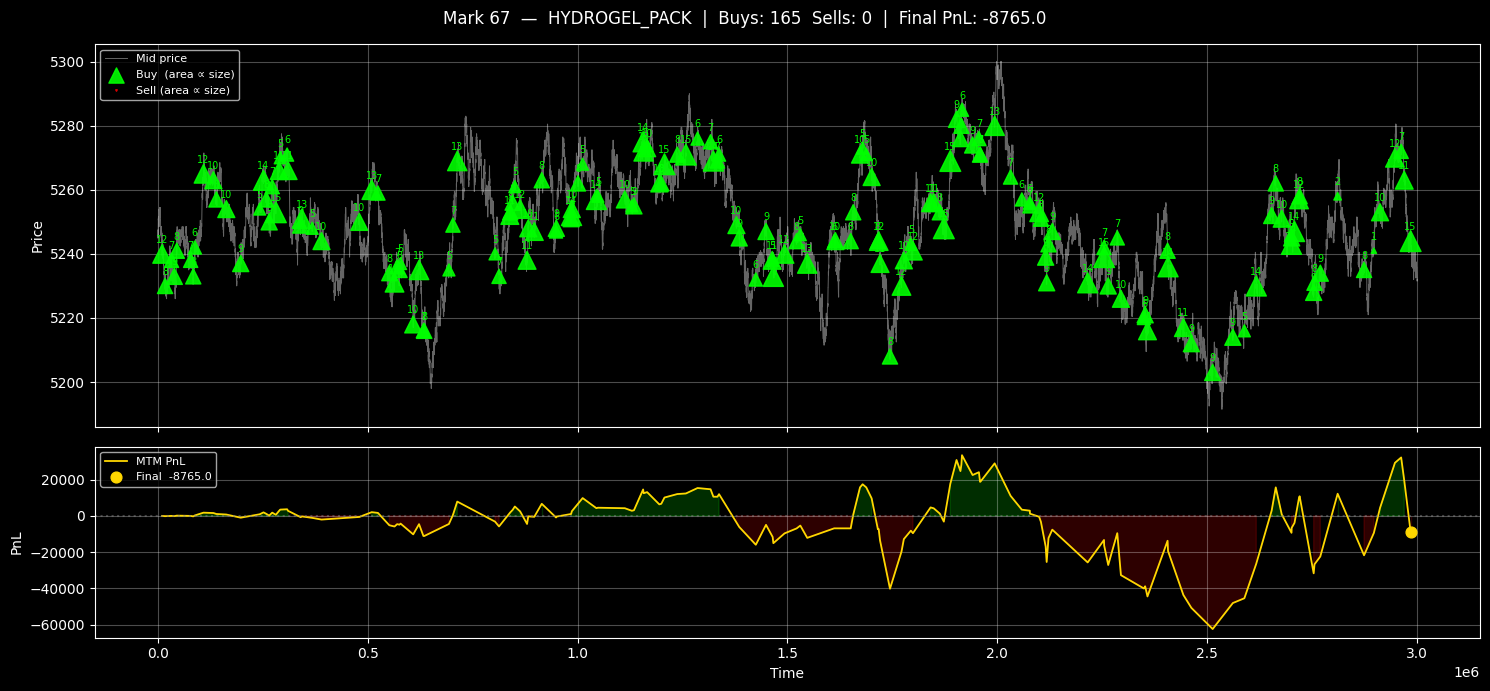

---
## VELVETFRUIT_EXTRACT Options — Normalized Price Comparison

`VEV_XXXX` are **call options** on `VELVETFRUIT_EXTRACT` with strike = XXXX.  
Each subplot normalizes both the option mid-price and the underlying to mean = 100, so their co-movement is directly comparable regardless of price scale.

In [ ]:
# ── VELVETFRUIT_EXTRACT options: normalized price comparison ──────────────────
# VEV_XXXX = European call options on VELVETFRUIT_EXTRACT, strike = XXXX.
# Deep-ITM options (VEV_4000) should track the underlying almost 1-for-1;
# OTM options (VEV_6000, VEV_6500) have near-zero premiums and higher leverage.

# -- underlying time series ---------------------------------------------------
underlying_df = prices_df[prices_df["product"] == "VELVETFRUIT_EXTRACT"].copy()
underlying_df = convert_timestamp(underlying_df)
underlying_ts = underlying_df.set_index("t")["mid_price"]

# -- discover all option symbols and sort by strike ---------------------------
option_symbols = sorted(
    [p for p in prices_df["product"].unique() if p.startswith("VEV_")],
    key=lambda s: int(s.split("_")[1]),
)
print(f"Underlying mean mid-price : {underlying_ts.mean():.1f}")
print(f"Options found             : {option_symbols}")

# -- build per-option series aligned to the underlying's time grid ------------
option_series = {}
for sym in option_symbols:
    df_opt = prices_df[prices_df["product"] == sym].copy()
    df_opt = convert_timestamp(df_opt)
    ts = df_opt.set_index("t")["mid_price"]
    option_series[sym] = ts.reindex(underlying_ts.index, method="ffill")

# ── grid of plots (2 columns) ─────────────────────────────────────────────────
ncols = 2
nrows = math.ceil(len(option_symbols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=True)
axes = axes.flatten()

for ax, sym in zip(axes, option_symbols):
    strike = int(sym.split("_")[1])
    opt_ts = option_series[sym]

    # keep only rows where the option has a meaningful (> 0) mid-price
    valid = (opt_ts > 0) & opt_ts.notna() & underlying_ts.notna()
    if valid.sum() < 20:
        ax.set_title(f"{sym}  —  insufficient non-zero data")
        ax.set_visible(False)
        continue

    und_v = underlying_ts[valid]
    opt_v = opt_ts[valid]
    t_idx = und_v.index

    # normalize both to mean = 100 so the y-axis is "% of mean"
    und_norm = (und_v / und_v.mean()) * 100
    opt_norm = (opt_v / opt_v.mean()) * 100

    moneyness = "ITM" if und_v.mean() > strike else "OTM"

    ax.plot(t_idx, und_norm, color="#ff69b4", linewidth=0.8, alpha=0.9,
            label="VELVETFRUIT_EXTRACT Mid")
    ax.plot(t_idx, opt_norm, color="#00ced1", linewidth=0.8, alpha=0.9,
            label=f"{sym} Mid")

    ax.set_title(
        f"Price Comparison: {sym} vs VELVETFRUIT_EXTRACT\n"
        f"Strike {strike}  |  {moneyness}  |  "
        f"Underlying μ = {und_v.mean():.0f}  |  Option μ = {opt_v.mean():.2f}",
        fontsize=9,
    )
    ax.set_ylabel("Normalized Price")
    ax.legend(loc="upper right", fontsize=7)
    ax.grid(True, alpha=0.3)

for ax in axes[len(option_symbols):]:
    ax.set_visible(False)

fig.suptitle(
    "VELVETFRUIT_EXTRACT Call Options — Normalized Mid-Price vs Underlying (mean = 100)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()